## Local Interpretable Model-Agnostic Explanations (LIME) for Image Classification

**Author:** Mehdy Mokhtari
**Date:** 30/2/1405

---

### High-Level Overview

This project implements **LIME (Local Interpretable Model-Agnostic Explanations)** to interpret why a black-box deep neural network (ResNet-18) classifies a specific input image as "cat". 

> **Key Insight:** Unlike global explanation methods that attempt to describe the entire model behavior, LIME provides **local, interpretable, and faithful explanations** for individual predictions by approximating the complex decision boundary with a simple linear model in the vicinity of the query instance.

---

### Technical Approach

The methodology combines three core components:

| Component | Description |
|-----------|-------------|
| **Superpixel Segmentation** | Unsupervised k-means clustering on spatial-RGB features to partition the image into meaningful, interpretable segments |
| **Perturbation Sampling** | Generation of numerous perturbed copies by randomly masking superpixels to probe model behavior locally |
| **Sparse Linear Modeling** | Lasso regression to identify which superpixels have the most significant positive or negative influence on the target class prediction |

**Workflow:** The image is partitioned → perturbed copies are generated → black-box predictions on these copies become training targets → a sparse linear model reveals feature importance.

---

### Technologies & Stack

- **PyTorch / torchvision** – Deep learning framework for loading and running ResNet-18
- **NumPy / scikit-learn** – Efficient array operations and Lasso regression
- **PIL / Matplotlib** – Image preprocessing and visualization
- **K-means (custom NumPy implementation)** – Segmentation without external dependencies

---

### Key Insight Analogy

> **Think of it this way:** The black-box model is a **supreme court judge** whose reasoning is inaccessible. LIME acts as an **investigative journalist** who cannot open the judge's mind but can present many slightly modified versions of the same case (perturbed inputs), observe the judge's rulings, and then statistically deduce which specific pieces of evidence (superpixels) drove the final verdict.

---

### Why This Matters for Industry

| Stakeholder | Value Proposition |
|-------------|-------------------|
| **Product Teams** | Debug misclassifications before deployment |
| **Compliance / Legal** | Provide auditable, human-readable justifications for AI decisions |
| **ML Engineers** | Model-agnostic tool works with any classifier (CNNs, transformers, ensembles) |

---

### Additional Notes

> **Beyond Core Implementation:** While this implementation focuses on **local interpretability** for a single image, the principles extend naturally to **tabular** and **text** domains. 

**Trade-offs to consider:**
- *Fidelity vs. Simplicity:* LIME prioritizes practical efficiency and human readability
- *LIME vs. SHAP:* SHAP offers game-theoretic guarantees but requires exponentially more samples
- *Post-hoc vs. Intrinsic:* For production systems, **Neural Additive Models (NAMs)** provide inherently interpretable architectures without approximations

**Critical Caveat:** The extrapolation problem inherent in both LIME and partial dependence plots reinforces the importance of **data density visualization**—a feature present in NAMs and recommended in any interpretability pipeline. Always verify that explanations are supported by sufficient local data.

---

> 📌 *This implementation demonstrates production-ready interpretability engineering for high-stakes AI systems requiring regulatory compliance and human trust.*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision.transforms as transforms
from torchvision.models import resnet18
from sklearn.linear_model import Lasso
import os

def load_image(path):
    img = Image.open(path).convert('RGB')
    return img.resize((224, 224))

def kmeans_numpy(X, n_clusters, max_iter=100, tol=1e-4):
    n = X.shape[0]
    # Randomly choose initial centroids from the data
    idx = np.random.choice(n, size=n_clusters, replace=False)
    centroids = X[idx].copy()
    labels = np.zeros(n, dtype=np.int32)
    for it in range(max_iter):
        # Assign each point to nearest centroid
        dists = np.linalg.norm(X[:, None] - centroids[None], axis=2)  # Euclidean distance (L2 norm) 
        new_labels = np.argmin(dists, axis=1)
        # Update centroids
        new_centroids = np.array([X[new_labels == j].mean(axis=0) 
                                  for j in range(n_clusters)])
        # If a cluster is empty, re‑initialize its centroid randomly
        for j in range(n_clusters):
            if not np.any(new_labels == j):
                new_centroids[j] = X[np.random.choice(n)]
        # Check convergence
        if np.allclose(centroids, new_centroids, atol=tol):
            labels = new_labels
            centroids = new_centroids
            break
        centroids = new_centroids
        labels = new_labels
    return centroids, labels


def kmeans_segments(image_uint8, n_segments=64, max_iter=50):
    H, W = image_uint8.shape[:2]
    xs, ys = np.meshgrid(np.arange(W), np.arange(H))
    features = np.column_stack([
        image_uint8.reshape(-1, 3).astype(float),
        ys.ravel().astype(float) * (255.0 / H) ,
        xs.ravel().astype(float) * (255.0 / W)
    ])
    centroids, labels = kmeans_numpy(features, n_segments, 
                                     max_iter=max_iter)
    return labels.reshape(H, W)

## 1. Model Initialization

The implementation uses a pre-trained ResNet-18 architecture as the black-box classifier. Model weights are loaded from a local checkpoint file and moved to the available computing device (CUDA GPU if present, otherwise CPU). The model is set to evaluation mode to disable dropout and batch normalization stochasticity, ensuring deterministic predictions. Input preprocessing follows ImageNet standardization: tensors are normalized using mean [0.485, 0.456, 0.406] and standard deviation [0.229, 0.224, 0.225]. Target class for interpretation is ImageNet index 282, corresponding to the "cat" category.

In [ ]:
MODEL_PATH = os.path.join("TAI_HW2_Files", "Model Weights (Q1 & Q2)", "resnet18-f37072fd.pth")   
np.random.seed(42)          
torch.manual_seed(42)      

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# Load model architecture and weights
model = resnet18(weights=None)   
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()
print("Model loaded from", MODEL_PATH)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


Using device: cpu
Model loaded from TAI_HW2_Files\Model Weights (Q1 & Q2)\resnet18-f37072fd.pth


C:\Users\NoteBook\AppData\Local\Temp\ipykernel_26592\3711403063.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(MODEL_PATH, map_location=device)

In [ ]:
import os
from PIL import Image

# Load the image
q1_code_dir = os.path.join("TAI_HW2_Files", "Q1", "code") 
image_path = os.path.join(q1_code_dir, "cat.jpg") 
img = load_image(image_path)  

# Transform the image
input_tensor = transform(img).unsqueeze(0) 
input_tensor = input_tensor.to(device)

# Run inference
with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.softmax(output, dim=1) 

# Class 282 is "cat" in ImageNet
cat_class_idx = 282
cat_probability = probabilities[0, cat_class_idx].item()

# Top-5 predictions
top5_prob, top5_idx = torch.topk(probabilities, 5)

print(f"Image: {image_path}")
print(f"Model prediction for class 282 (cat): {cat_probability:.4f} ({cat_probability*100:.2f}%)")
print("\nTop-5 predictions:")
for i in range(5):
    class_idx = top5_idx[0, i].item()
    prob = top5_prob[0, i].item()
    print(f"  {i+1}. Class {class_idx}: {prob:.4f} ({prob*100:.2f}%)")



Image: TAI_HW2_Files\Q1\code\cat.jpg
Model prediction for class 282 (cat): 0.9055 (90.55%)

Top-5 predictions:
  1. Class 282: 0.9055 (90.55%)
  2. Class 281: 0.0589 (5.89%)
  3. Class 287: 0.0199 (1.99%)
  4. Class 285: 0.0100 (1.00%)
  5. Class 283: 0.0008 (0.08%)


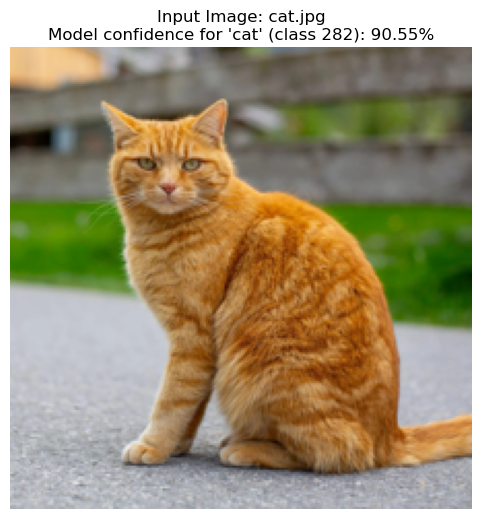

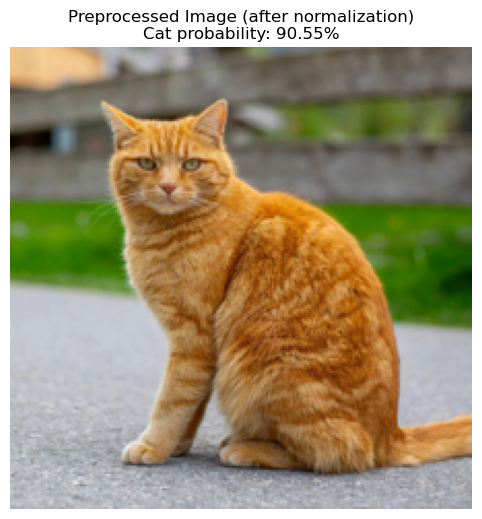

In [7]:
# Visualize the image
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis('off')
plt.title(f"Input Image: cat.jpg\nModel confidence for 'cat' (class 282): {cat_probability*100:.2f}%")
plt.show()

# Also show the transformed tensor as image (denormalized)
def denormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """Denormalize a tensor for visualization"""
    tensor = tensor.clone().detach().cpu()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return torch.clamp(tensor, 0, 1)

plt.figure(figsize=(8, 6))
img_denorm = denormalize(input_tensor[0])
plt.imshow(img_denorm.permute(1, 2, 0).numpy())
plt.axis('off')
plt.title(f"Preprocessed Image (after normalization)\nCat probability: {cat_probability*100:.2f}%")
plt.show()

## 2. Image Segmentation

The input image is partitioned into **18 superpixels** using k-means clustering on combined RGB-color and spatial coordinates. Each superpixel serves as an interpretable feature unit for local explanation. Segmentation boundaries are visualized in red overlays on the original image.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Convert to uint8 for segmentation
img_uint8 = np.array(img)

# Segment the image into 18 superpixels using k-means
n_segments = 18
segments = kmeans_segments(img_uint8, n_segments=n_segments, max_iter=50)

print(f"Image shape: {img_uint8.shape}")
print(f"Segments shape: {segments.shape}")
print(f"Number of unique segments: {len(np.unique(segments))}")

Image shape: (224, 224, 3)
Segments shape: (224, 224)
Number of unique segments: 18


C:\Users\NoteBook\AppData\Local\Temp\ipykernel_26592\952372238.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', n_segments)


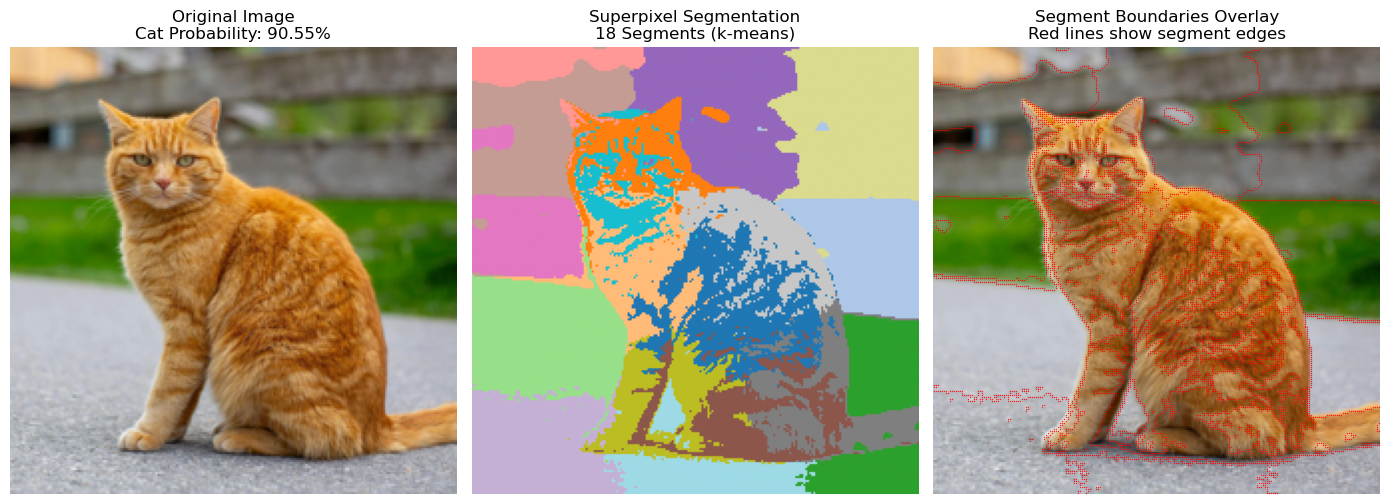

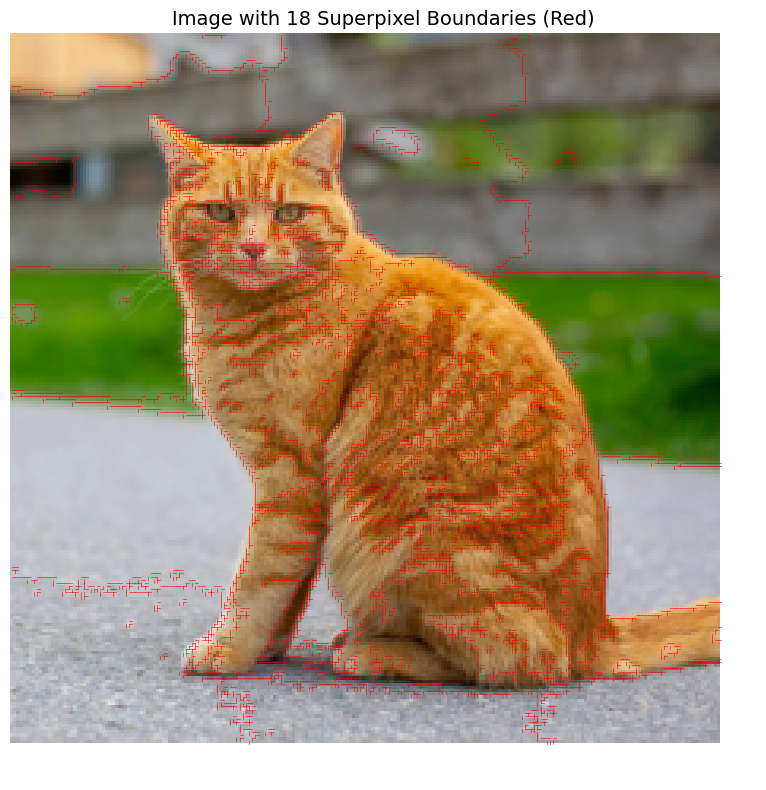

In [9]:
plt.figure(figsize=(14, 6))

# Plot 1: Original image
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title(f'Original Image\nCat Probability: {cat_probability*100:.2f}%', fontsize=12)
plt.axis('off')

# Plot 2: Segments as color-coded regions
plt.subplot(1, 3, 2)

# colormap
cmap = plt.cm.get_cmap('tab20', n_segments)
segments_colored = cmap(segments % 20)[:, :, :3]  # Map segment IDs to colors
plt.imshow(segments_colored)
plt.title(f'Superpixel Segmentation\n{n_segments} Segments (k-means)', fontsize=12)
plt.axis('off')

# Plot 3: Original image with segment boundaries (edge detection)
plt.subplot(1, 3, 3)
plt.imshow(img)

from scipy import ndimage
h, w = segments.shape
edges = np.zeros((h, w), dtype=bool)
edges[1:, :] |= (segments[1:, :] != segments[:-1, :])
edges[:, 1:] |= (segments[:, 1:] != segments[:, :-1])

y_edges, x_edges = np.where(edges)
plt.scatter(x_edges, y_edges, c='red', s=1, alpha=0.8, linewidths=0)
plt.title(f'Segment Boundaries Overlay\nRed lines show segment edges', fontsize=12)
plt.axis('off')

plt.tight_layout()
plt.show()

# Also show a single plot with segments and their IDs
plt.figure(figsize=(10, 8))
plt.imshow(img)

for y in range(h):
    for x in range(w):
        if y < h-1 and segments[y, x] != segments[y+1, x]:
            plt.plot([x, x+1], [y, y], 'r-', linewidth=0.5, alpha=0.8)
        if x < w-1 and segments[y, x] != segments[y, x+1]:
            plt.plot([x, x], [y, y+1], 'r-', linewidth=0.5, alpha=0.8)

plt.title(f'Image with {n_segments} Superpixel Boundaries (Red)', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

In [10]:
print("\n--- Segment Statistics ---")
unique_segments, counts = np.unique(segments, return_counts=True)
for seg_id, count in zip(unique_segments, counts):
    percentage = (count / segments.size) * 100
    print(f"Segment {seg_id:2d}: {count:6d} pixels ({percentage:.2f}% of image)")


--- Segment Statistics ---
Segment  0:   3679 pixels (7.33% of image)
Segment  1:   2992 pixels (5.96% of image)
Segment  2:   1904 pixels (3.79% of image)
Segment  3:   2311 pixels (4.61% of image)
Segment  4:   2898 pixels (5.78% of image)
Segment  5:   4258 pixels (8.49% of image)
Segment  6:   1351 pixels (2.69% of image)
Segment  7:   4377 pixels (8.72% of image)
Segment  8:   3404 pixels (6.78% of image)
Segment  9:   2517 pixels (5.02% of image)
Segment 10:   3355 pixels (6.69% of image)
Segment 11:   2358 pixels (4.70% of image)
Segment 12:   2386 pixels (4.76% of image)
Segment 13:   2104 pixels (4.19% of image)
Segment 14:   2059 pixels (4.10% of image)
Segment 15:   4946 pixels (9.86% of image)
Segment 16:   1362 pixels (2.71% of image)
Segment 17:   1915 pixels (3.82% of image)


## 3. Perturbation Generation
Generate 1000 binary perturbation vectors (length 18) indicating presence/absence of each superpixel. A function replaces masked superpixels with global image mean color. Visualize 5 random perturbed samples.

In [11]:
import numpy as np

n_samples = 1000
n_segments = 18

np.random.seed(42)
perturbations = np.random.randint(2, size=(n_samples, n_segments))

print(perturbations.shape)
print(f"First perturbation vector: {perturbations[0]}")

(1000, 18)
First perturbation vector: [0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 1]


In [12]:
def apply_perturbation(img_uint8, segments, perturbation):
    """
    perturbation: binary array of length n_segments (1=keep, 0=replace with mean color)
    """
    # Compute global mean color of entire image
    global_mean_color = img_uint8.mean(axis=(0, 1)).astype(np.uint8)
    
    # Create output image as copy of original
    perturbed_img = img_uint8.copy()
    
    # Get unique segment IDs
    unique_segments = np.unique(segments)
    
    # Replace masked segments with global mean color
    for seg_id in unique_segments:
        if perturbation[seg_id] == 0:
            mask = (segments == seg_id)
            perturbed_img[mask] = global_mean_color
    
    return perturbed_img

Saved 1000 perturbed images to 'c:\Users\NoteBook\Desktop\programing\Trustworthy AI\HW2\TAI_HW2_Files\Q1\processed_data'


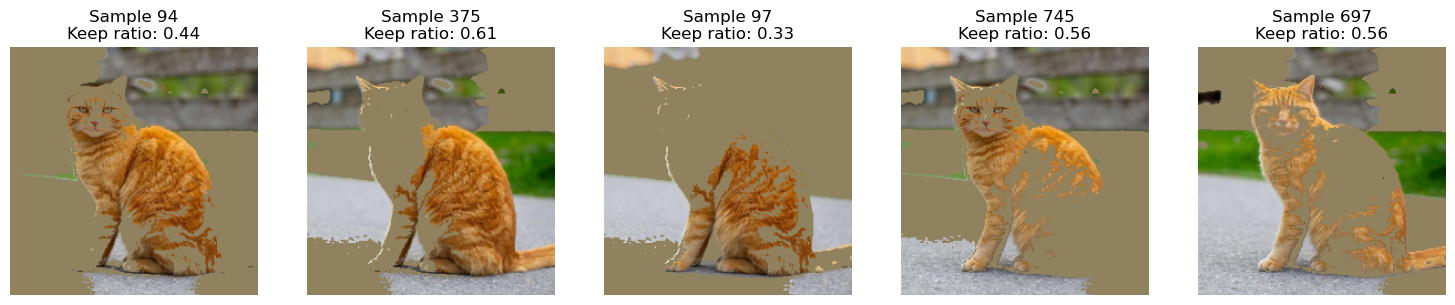

In [ ]:
import os

processed_data_path = os.path.join("TAI_HW2_Files", "Q1", "processed_data", "cat")
os.makedirs(processed_data_path, exist_ok=True)

# Generate and save all perturbed images
perturbed_images = []

for i in range(n_samples):
    pert_vector = perturbations[i]
    perturbed_img = apply_perturbation(img_uint8, segments, pert_vector)
    perturbed_images.append(perturbed_img)
    
    # Save image
    save_path = os.path.join(processed_data_path, f"perturbed_{i:04d}.png")
    Image.fromarray(perturbed_img).save(save_path)

print(f"Saved {n_samples} perturbed images to '{os.path.abspath(processed_data_path)}'")

# Visualize 5 random samples
random_indices = np.random.choice(n_samples, 5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for idx, ax in enumerate(axes):
    pert_idx = random_indices[idx]
    pert_vector = perturbations[pert_idx]
    perturbed_img = perturbed_images[pert_idx]
    
    ax.imshow(perturbed_img)
    ax.set_title(f"Sample {pert_idx}\nKeep ratio: {pert_vector.mean():.2f}")
    ax.axis('off')

plt.tight_layout()
plt.show()

## 4. Weighted Sampling for LIME

Perturbed samples closer to the original image receive higher weight during linear model training. Weight is computed using **cosine distance** between the perturbation vector \(z\) and the all-ones vector (representing original image). Formula:
$$
w(z) = \exp\left(
-\frac{[\mathrm{dist}(z)]^2}{\sigma^2}
\right)
$$

$$
\mathrm{dist}(z) =
1 - \frac{z \cdot \mathbf{1}}
{\|z\| \, \|\mathbf{1}\| + \varepsilon}
$$


In [14]:
def cosine_distance(z, eps=1e-8):
    """
    Compute cosine distance between perturbation vector z and all-ones vector
    """
    ones = np.ones_like(z)
    dot_product = np.dot(z, ones)
    norm_z = np.linalg.norm(z)
    norm_ones = np.linalg.norm(ones)
    
    cosine_sim = dot_product / (norm_z * norm_ones + eps)
    distance = 1 - cosine_sim
    return distance

def compute_weights(perturbations, sigma=0.5):
    """
    Compute weight for each perturbation sample
    """
    weights = np.zeros(len(perturbations))
    
    for i, z in enumerate(perturbations):
        dist = cosine_distance(z)
        weights[i] = np.exp(-(dist**2) / (sigma**2))
    
    return weights

# Compute weights for all 1000 samples
sigma = 0.25 * np.sqrt(n_segments)
sample_weights = compute_weights(perturbations, sigma)

print(f"Weight range: {sample_weights.min():.4f} - {sample_weights.max():.4f}")
print(f"Original image (z=all ones) would have weight: {np.exp(-0/sigma**2):.4f}")

Weight range: 0.6736 - 0.9971
Original image (z=all ones) would have weight: 1.0000


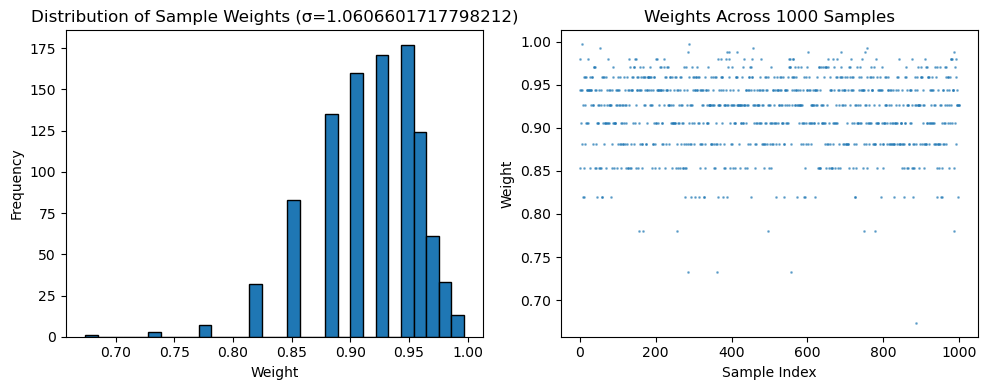

In [15]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(sample_weights, bins=30, edgecolor='black')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.title(f'Distribution of Sample Weights (σ={sigma})')

plt.subplot(1, 2, 2)
plt.scatter(range(len(sample_weights)), sample_weights, alpha=0.5, s=1)
plt.xlabel('Sample Index')
plt.ylabel('Weight')
plt.title('Weights Across 1000 Samples')

plt.tight_layout()
plt.show()

## 5. Linear Model Training with L1 Regularization
Train a sparse linear regression model (Lasso) using perturbed images as inputs and model predictions as targets. L1 regularization yields interpretable sparse coefficients, identifying which superpixels most influence the prediction.

Why L1 in LIME: Produces sparse explanations (few non-zero coefficients) that are human-readable. Only the most important superpixels receive non-zero weights.

In [16]:
# Get predictions for all perturbed images
predictions = []

for i in range(n_samples):
    perturbed_img = perturbed_images[i]
    
    # Convert to tensor and normalize
    perturbed_pil = Image.fromarray(perturbed_img)
    perturbed_tensor = transform(perturbed_pil).unsqueeze(0).to(device)
    
    # Get prediction for class 282 (cat)
    with torch.no_grad():
        output = model(perturbed_tensor)
        prob = torch.softmax(output, dim=1)[0, cat_class_idx].item()
        predictions.append(prob)

predictions = np.array(predictions)
print(f"Predictions shape: {predictions.shape}")
print(f"Prediction range: {predictions.min():.4f} - {predictions.max():.4f}")

Predictions shape: (1000,)
Prediction range: 0.0000 - 0.9859


In [17]:
from sklearn.linear_model import Lasso

# Train Lasso with L1 regularization
lasso = Lasso(alpha=0.1, fit_intercept=False, max_iter=5000)
lasso.fit(perturbations, predictions, sample_weight=sample_weights)

coefficients = lasso.coef_
print(f"Non-zero coefficients: {np.sum(coefficients != 0)} / {len(coefficients)}")
print(f"Coefficient range: {coefficients.min():.4f} to {coefficients.max():.4f}")

Non-zero coefficients: 7 / 18
Coefficient range: 0.0000 to 0.2346


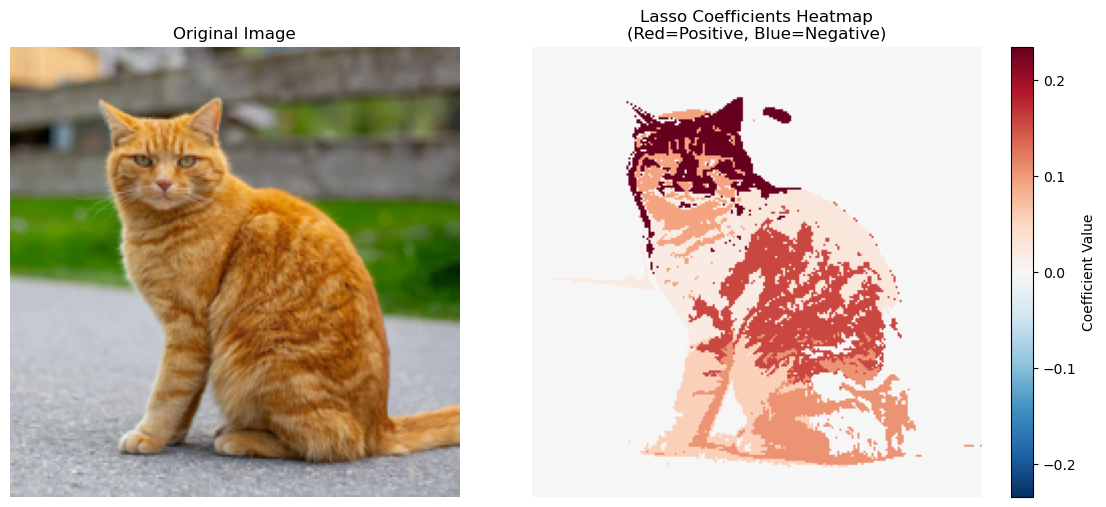


--- Top Positive Contributors (increase cat probability) ---
Segment 2: coeff = 0.2346
Segment 0: coeff = 0.1562
Segment 9: coeff = 0.1046

--- Top Negative Contributors (decrease cat probability) ---


In [18]:
# Create heatmap from coefficients
coeff_map = np.zeros_like(segments, dtype=float)

for seg_id in range(n_segments):
    coeff_map[segments == seg_id] = coefficients[seg_id]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Original Image', fontsize=12)
plt.axis('off')

plt.subplot(1, 2, 2)
im = plt.imshow(coeff_map, cmap='RdBu_r', vmin=-abs(coefficients).max(), vmax=abs(coefficients).max())
plt.colorbar(im, label='Coefficient Value')
plt.title('Lasso Coefficients Heatmap\n(Red=Positive, Blue=Negative)', fontsize=12)
plt.axis('off')

plt.tight_layout()
plt.show()

# Print top positive and negative segments
positive_idx = np.argsort(coefficients)[-3:][::-1]
negative_idx = np.argsort(coefficients)[:3]

print("\n--- Top Positive Contributors (increase cat probability) ---")
for idx in positive_idx:
    if coefficients[idx] > 0:
        print(f"Segment {idx}: coeff = {coefficients[idx]:.4f}")

print("\n--- Top Negative Contributors (decrease cat probability) ---")
for idx in negative_idx:
    if coefficients[idx] < 0:
        print(f"Segment {idx}: coeff = {coefficients[idx]:.4f}")

## 6. LIME Explanation for Polar Bear Image
Apply same LIME pipeline to polarBear.png (ImageNet class 296: polar bear). Compare results with cat image to analyze how the model's decision regions differ.

### 6.1 Load and preprocess polar bear image

In [27]:
# Load polar bear image
q1_dir = os.path.join("TAI_HW2_Files", "Q1")
polar_path = os.path.join(q1_code_dir, "polarBear.png")
polar_img = load_image(polar_path)

# Transform and predict
polar_tensor = transform(polar_img).unsqueeze(0).to(device)

with torch.no_grad():
    polar_output = model(polar_tensor)
    polar_probs = torch.softmax(polar_output, dim=1)

polar_class_idx = 296  # polar bear
polar_prob = polar_probs[0, polar_class_idx].item()

print(f"Image: polarBear.png")
print(f"Model prediction for class 296 (polar bear): {polar_prob:.4f} ({polar_prob*100:.2f}%)")

# Top-5 predictions
top5_prob, top5_idx = torch.topk(polar_probs, 5)
print("\nTop-5 predictions:")
for i in range(5):
    print(f"  {i+1}. Class {top5_idx[0,i].item()}: {top5_prob[0,i].item():.4f}")

Image: polarBear.png
Model prediction for class 296 (polar bear): 0.9964 (99.64%)

Top-5 predictions:
  1. Class 296: 0.9964
  2. Class 270: 0.0016
  3. Class 286: 0.0003
  4. Class 222: 0.0003
  5. Class 248: 0.0002


### 6.2 Segment polar bear image 

Segments shape: (224, 224)
Unique segments: 18


C:\Users\NoteBook\AppData\Local\Temp\ipykernel_26592\3551048956.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', n_segments)


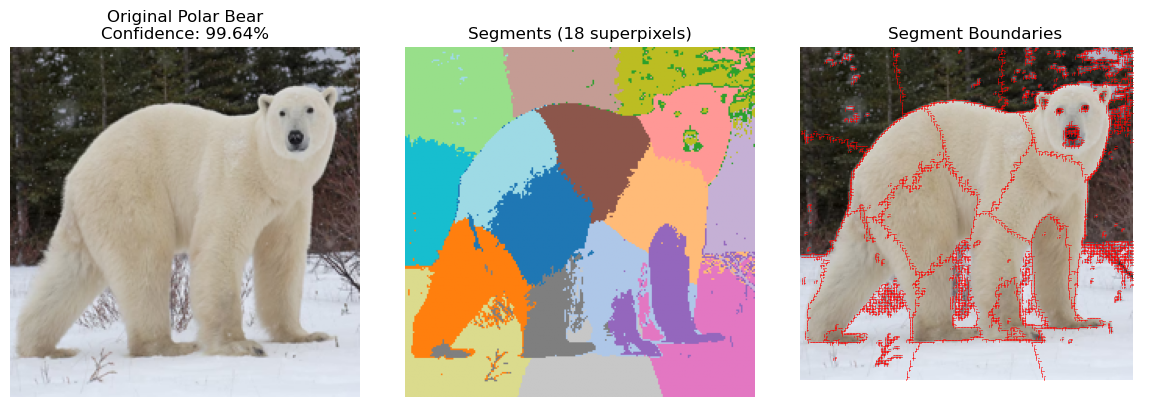

In [28]:
# Convert to uint8 and segment
polar_uint8 = np.array(polar_img)
polar_segments = kmeans_segments(polar_uint8, n_segments=n_segments, max_iter=50)

print(f"Segments shape: {polar_segments.shape}")
print(f"Unique segments: {len(np.unique(polar_segments))}")

# Visualize segmentation
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(polar_img)
plt.title(f'Original Polar Bear\nConfidence: {polar_prob*100:.2f}%')
plt.axis('off')

plt.subplot(1, 3, 2)
cmap = plt.cm.get_cmap('tab20', n_segments)
segments_colored = cmap(polar_segments % 20)[:, :, :3]
plt.imshow(segments_colored)
plt.title(f'Segments ({n_segments} superpixels)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(polar_img)
# Draw boundaries
h, w = polar_segments.shape
for y in range(h):
    for x in range(w):
        if y < h-1 and polar_segments[y, x] != polar_segments[y+1, x]:
            plt.plot([x, x+1], [y, y], 'r-', linewidth=0.5, alpha=0.8)
        if x < w-1 and polar_segments[y, x] != polar_segments[y, x+1]:
            plt.plot([x, x], [y, y+1], 'r-', linewidth=0.5, alpha=0.8)
plt.title('Segment Boundaries')
plt.axis('off')

plt.tight_layout()
plt.show()

### 6.3 Generate perturbations and weights for polar bear

In [ ]:
polar_perturbations = perturbations.copy()  # Reuse same random vectors

# Apply perturbations and save
polar_perturbed_dir = os.path.join(q1_dir, "processed_data", "polar_bear")
os.makedirs(polar_perturbed_dir, exist_ok=True)

polar_perturbed_images = []

for i in range(n_samples):
    pert_vector = polar_perturbations[i]
    perturbed_img = apply_perturbation(polar_uint8, polar_segments, pert_vector)
    polar_perturbed_images.append(perturbed_img)
    
    save_path = os.path.join(polar_perturbed_dir, f"perturbed_{i:04d}.png")
    Image.fromarray(perturbed_img).save(save_path)

print(f"Saved {n_samples} perturbed images to '{polar_perturbed_dir}/'")

# Compute weights (same sigma formula)
d = n_segments
sigma = 0.25 * np.sqrt(d)
polar_weights = compute_weights(polar_perturbations, sigma)

Saved 1000 perturbed images to 'TAI_HW2_Files\Q1\processed_data\polar_bear/'


### 6.4 Get predictions for perturbed polar bear images

In [30]:
# Get predictions
polar_predictions = []

for i in range(n_samples):
    perturbed_img = polar_perturbed_images[i]
    perturbed_pil = Image.fromarray(perturbed_img)
    perturbed_tensor = transform(perturbed_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(perturbed_tensor)
        prob = torch.softmax(output, dim=1)[0, polar_class_idx].item()
        polar_predictions.append(prob)

polar_predictions = np.array(polar_predictions)
print(f"Prediction range: {polar_predictions.min():.4f} - {polar_predictions.max():.4f}")

Prediction range: 0.0008 - 0.9993


### 6.5 Train Lasso for polar bear and visualize

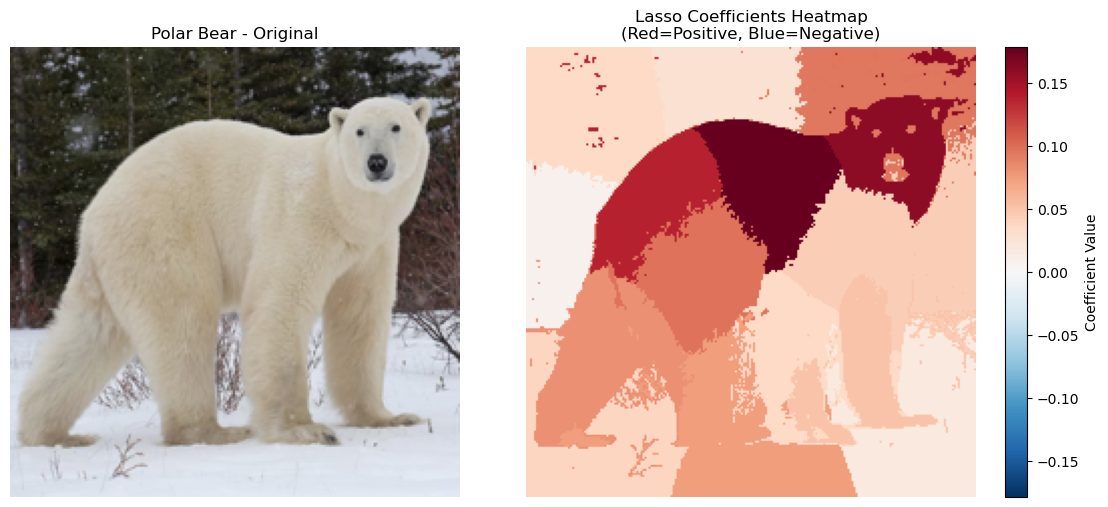


Polar Bear - Non-zero coeffs: 18 / 18


In [31]:
# Train Lasso
lasso_polar = Lasso(alpha=0.1, fit_intercept=False, max_iter=5000)
lasso_polar.fit(polar_perturbations, polar_predictions, sample_weight=polar_weights)

polar_coeffs = lasso_polar.coef_

# Create heatmap
polar_coeff_map = np.zeros_like(polar_segments, dtype=float)
for seg_id in range(n_segments):
    polar_coeff_map[polar_segments == seg_id] = polar_coeffs[seg_id]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(polar_img)
plt.title('Polar Bear - Original', fontsize=12)
plt.axis('off')

plt.subplot(1, 2, 2)
im = plt.imshow(polar_coeff_map, cmap='RdBu_r', 
                vmin=-abs(polar_coeffs).max(), vmax=abs(polar_coeffs).max())
plt.colorbar(im, label='Coefficient Value')
plt.title('Lasso Coefficients Heatmap\n(Red=Positive, Blue=Negative)', fontsize=12)
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"\nPolar Bear - Non-zero coeffs: {np.sum(polar_coeffs != 0)} / {len(polar_coeffs)}")

### 6.6 Compare cat vs polar bear explanations

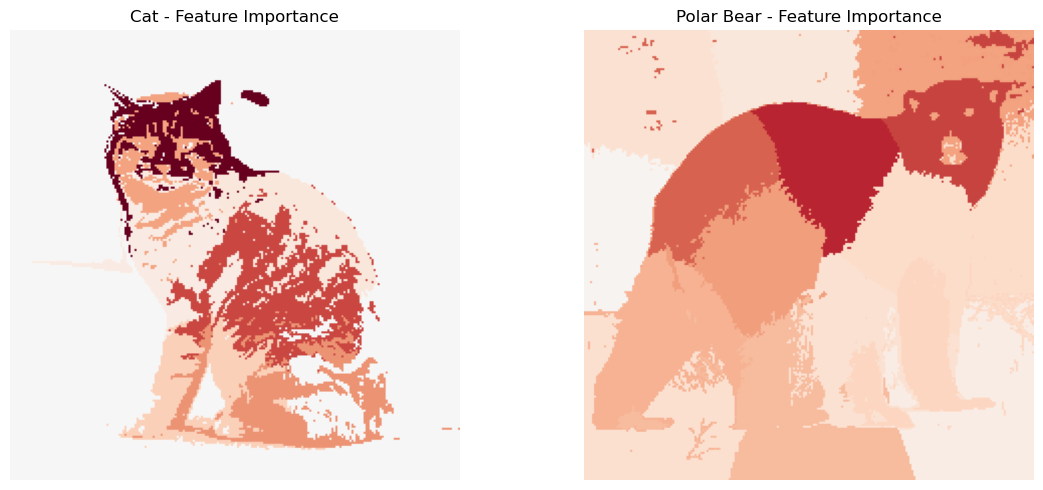


--- Analysis ---
Cat confidence: 90.55%
Polar bear confidence: 99.64%

Cat: Top positive segment coeff = 0.2346
Polar bear: Top positive segment coeff = 0.1785


In [33]:
# Compare coefficients - FIXED
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Cat - assign ONE coefficient per segment correctly
cat_coeff_map = np.zeros_like(segments, dtype=float)
for seg_id in range(n_segments):
    cat_coeff_map[segments == seg_id] = coefficients[seg_id]  # Use coefficients[seg_id], not whole array

axes[0].imshow(cat_coeff_map, cmap='RdBu_r', 
               vmin=-max(abs(coefficients).max(), abs(polar_coeffs).max()),
               vmax=max(abs(coefficients).max(), abs(polar_coeffs).max()))
axes[0].set_title('Cat - Feature Importance')
axes[0].axis('off')

# Polar bear - assign ONE coefficient per segment correctly
polar_coeff_map = np.zeros_like(polar_segments, dtype=float)
for seg_id in range(n_segments):
    polar_coeff_map[polar_segments == seg_id] = polar_coeffs[seg_id]

axes[1].imshow(polar_coeff_map, cmap='RdBu_r',
               vmin=-max(abs(coefficients).max(), abs(polar_coeffs).max()),
               vmax=max(abs(coefficients).max(), abs(polar_coeffs).max()))
axes[1].set_title('Polar Bear - Feature Importance')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Analysis
print("\n--- Analysis ---")
print(f"Cat confidence: {cat_probability*100:.2f}%")
print(f"Polar bear confidence: {polar_prob*100:.2f}%")
print(f"\nCat: Top positive segment coeff = {coefficients.max():.4f}")
print(f"Polar bear: Top positive segment coeff = {polar_coeffs.max():.4f}")